In [1]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 2.7 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.6 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


## Импорты

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRanker, Pool
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

USE_GPU = True

if USE_GPU:
    try:
        from implicit.gpu.als import AlternatingLeastSquares
        print("implicit: используется GPU")
    except ImportError:
        from implicit.als import AlternatingLeastSquares
        print("implicit: GPU недоступен, используется CPU")
else:
    from implicit.als import AlternatingLeastSquares
    print("implicit: используется CPU")

CATBOOST_TASK_TYPE = 'GPU' if USE_GPU else 'CPU'
print(f"CatBoost: task_type='{CATBOOST_TASK_TYPE}'")

In [2]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Размер исходного датасета: {df.shape}")

Размер исходного датасета: (610913, 16)


In [3]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

print(f"После фильтрации: {df_filtered.shape}")
print(f"Диапазон дат: {df_filtered['Дата'].min()} — {df_filtered['Дата'].max()}")

После фильтрации: (420857, 16)
Диапазон дат: 2017-03-01 00:03:00 — 2017-04-30 23:58:00


In [ ]:
MIN_INTERACTIONS = 3

for _ in range(5):
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

print(f"После фильтрации (≥{MIN_INTERACTIONS} покупок):")
print(f"  Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"  Товаров: {df_filtered['ID_SKU'].nunique():,}")
print(f"  Взаимодействий: {len(df_filtered):,}")

После фильтрации (≥5 покупок):
  Пользователей: 17,442
  Товаров: 8,488
  Взаимодействий: 227,170


In [5]:
# Кодирование пользователей и товаров
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')
interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])

user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)
print(f"Пользователей: {n_users:,}, Товаров: {n_items:,}")

Пользователей: 17,442, Товаров: 8,488


In [ ]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'],
    how='inner'
).sort_values('Дата')

split_date = interactions_with_date['Дата'].quantile(0.7)
train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data  = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()

print(f"Дата разделения: {split_date}")
print(f"Train: {len(train_data):,} | Test: {len(test_data):,}")

Дата разделения: 2017-04-18 05:36:00
Train: 181,716 | Test: 45,454


In [7]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions  = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

def create_sparse_matrix(interactions_df, n_users, n_items):
    return csr_matrix(
        (interactions_df['count'].values,
         (interactions_df['user_id'].values, interactions_df['item_id'].values)),
        shape=(n_users, n_items)
    )

train_matrix = create_sparse_matrix(train_interactions, n_users, n_items)
test_matrix  = create_sparse_matrix(test_interactions, n_users, n_items)

print(f"Train matrix: {train_matrix.shape}, nnz={train_matrix.nnz:,}")
print(f"Test matrix:  {test_matrix.shape}, nnz={test_matrix.nnz:,}")

Train matrix: (17442, 8488), nnz=165,095
Test matrix:  (17442, 8488), nnz=44,150


In [8]:
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=15,
    calculate_training_loss=True,
    random_state=42
)
als_model.fit(train_matrix)
print("ALS обучен")
print(f"User factors shape: {als_model.user_factors.shape}")
print(f"Item factors shape: {als_model.item_factors.shape}")

  0%|          | 0/15 [00:00<?, ?it/s]

ALS обучен
User factors shape: (17442, 50)
Item factors shape: (8488, 50)


In [9]:
# Признаки пользователей из обучающих данных
user_features = train_data.groupby('user_id').agg(
    user_n_purchases=('count', 'sum'),
    user_n_unique_items=('item_id', 'nunique'),
    user_avg_price=('Цена', 'mean'),
    user_total_margin=('Маржа', 'sum'),
    user_avg_margin=('Маржа', 'mean'),
).reset_index()

# Гео (мода)
user_geo = train_data.groupby('user_id')['Гео'].agg(lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно').reset_index()
user_geo.columns = ['user_id', 'user_geo']

# Метод доставки (мода)
user_delivery = train_data.groupby('user_id')['МетодДоставки_Групп'].agg(lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно').reset_index()
user_delivery.columns = ['user_id', 'user_delivery_method']

user_features = user_features.merge(user_geo, on='user_id').merge(user_delivery, on='user_id')
print(f"User features shape: {user_features.shape}")
user_features.head(3)

User features shape: (15550, 8)


,user_id,user_n_purchases,user_n_unique_items,user_avg_price,user_total_margin,user_avg_margin,user_geo,user_delivery_method
0,0,9,9,395.888889,858.85,95.427778,МО,Магазины
1,2,5,5,538.800000,383.39,76.678000,Регионы,Магазины
2,4,6,6,156.333333,276.29,46.048333,Регионы,Магазины


In [10]:
# Признаки товаров из обучающих данных
item_features = train_data.groupby('item_id').agg(
    item_n_purchases=('count', 'sum'),
    item_n_unique_buyers=('user_id', 'nunique'),
    item_avg_price=('Цена', 'mean'),
    item_avg_margin=('Маржа', 'mean'),
).reset_index()

# Категория товара (мода Группа2)
item_category = train_data.groupby('item_id')['Группа2'].agg(lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно').reset_index()
item_category.columns = ['item_id', 'item_category']

item_features = item_features.merge(item_category, on='item_id')
print(f"Item features shape: {item_features.shape}")
item_features.head(3)

Item features shape: (8399, 6)


,item_id,item_n_purchases,item_n_unique_buyers,item_avg_price,item_avg_margin,item_category
0,0,3,3,98.000000,30.680000,ИГРУШКИ
1,1,5,5,55.540000,24.368000,ИГРУШКИ
2,2,83,70,72.013514,13.934324,КОСМЕТИКА/ГИГИЕНА


In [ ]:

train_user_set = set(train_interactions['user_id'].unique())
test_user_items = test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()


eval_users = [u for u in test_user_items if u in train_user_set]
print(f"Пользователей для оценки (warm): {len(eval_users):,}")
print(f"Cold-start пользователей: {len(test_user_items) - len(eval_users):,}")

Пользователей для оценки (warm): 4,196
Cold-start пользователей: 1,892


In [ ]:
N_CANDIDATES = 100

rows = []
for user_id in eval_users:
    item_ids, scores = als_model.recommend(
        user_id,
        train_matrix[user_id],
        N=N_CANDIDATES,
        filter_already_liked_items=True
    )
    relevant = set(test_user_items[user_id])
    for rank, (item_id, score) in enumerate(zip(item_ids, scores)):
        rows.append({
            'user_id': user_id,
            'item_id': int(item_id),
            'als_score': float(score),
            'als_rank': rank + 1,
            'label': int(int(item_id) in relevant)
        })

candidates_df = pd.DataFrame(rows)
print(f"Сгенерировано кандидатов: {len(candidates_df):,}")
print(f"Доля положительных: {candidates_df['label'].mean():.4f}")

Сгенерировано кандидатов: 419,600
Доля положительных: 0.0097


In [ ]:

dataset = candidates_df.merge(user_features, on='user_id', how='left')
dataset = dataset.merge(item_features, on='item_id', how='left')

user_factors = als_model.user_factors
item_factors = als_model.item_factors

u_vecs = user_factors[dataset['user_id'].values]
i_vecs = item_factors[dataset['item_id'].values]
dataset['als_dot'] = (u_vecs * i_vecs).sum(axis=1)
dataset['als_user_norm'] = np.linalg.norm(u_vecs, axis=1)
dataset['als_item_norm'] = np.linalg.norm(i_vecs, axis=1)
dataset['als_cosine'] = dataset['als_dot'] / (
    dataset['als_user_norm'] * dataset['als_item_norm'] + 1e-10
)

print(f"Dataset shape: {dataset.shape}")
dataset.head(3)

Dataset shape: (419600, 21)


,user_id,item_id,als_score,als_rank,label,user_n_purchases,user_n_unique_items,user_avg_price,user_total_margin,user_avg_margin,...,user_delivery_method,item_n_purchases,item_n_unique_buyers,item_avg_price,item_avg_margin,item_category,als_dot,als_user_norm,als_item_norm,als_cosine
0,5,653,0.520589,1,0,20,13,152.307692,186.58,14.352308,...,Курьерская,316,255,25.830882,6.821801,ДЕТСКОЕ ПИТАНИЕ,0.520589,2.268092,0.333173,0.688912
1,5,652,0.481822,2,1,20,13,152.307692,186.58,14.352308,...,Курьерская,330,232,25.984314,5.802784,ДЕТСКОЕ ПИТАНИЕ,0.481821,2.268092,0.320176,0.663495
2,5,6683,0.390545,3,0,20,13,152.307692,186.58,14.352308,...,Курьерская,342,283,28.336700,11.775892,ДЕТСКОЕ ПИТАНИЕ,0.390545,2.268092,0.321734,0.535197


In [14]:
# Заполняем пропуски
num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if col not in ['user_id', 'item_id', 'label']:
        dataset[col] = dataset[col].fillna(dataset[col].median())

dataset['user_geo'] = dataset['user_geo'].fillna('Неизвестно')
dataset['user_delivery_method'] = dataset['user_delivery_method'].fillna('Неизвестно')
dataset['item_category'] = dataset['item_category'].fillna('Неизвестно')

print("Пропуски:", dataset.isnull().sum().sum())

Пропуски: 0


In [15]:
# Разбиваем пользователей 80/20 для CatBoost
all_users = dataset['user_id'].unique()
np.random.seed(42)
np.random.shuffle(all_users)

split_idx = int(len(all_users) * 0.8)
cb_train_users = set(all_users[:split_idx])
cb_val_users   = set(all_users[split_idx:])

# Сортировка по user_id обязательна для CatBoostRanker
cb_train = dataset[dataset['user_id'].isin(cb_train_users)].sort_values('user_id').copy()
cb_val   = dataset[dataset['user_id'].isin(cb_val_users)].sort_values('user_id').copy()

print(f"CatBoost train: {len(cb_train):,} строк, {len(cb_train_users):,} пользователей")
print(f"CatBoost val:   {len(cb_val):,} строк, {len(cb_val_users):,} пользователей")

CatBoost train: 335,600 строк, 3,356 пользователей
CatBoost val:   84,000 строк, 840 пользователей


In [ ]:
FEATURE_COLS = [
    'als_score', 'als_rank', 'als_dot', 'als_cosine',
    'als_user_norm', 'als_item_norm',
    'user_n_purchases', 'user_n_unique_items', 'user_avg_price',
    'user_total_margin', 'user_avg_margin',
    'user_geo', 'user_delivery_method',
    'item_n_purchases', 'item_n_unique_buyers',
    'item_avg_price', 'item_avg_margin', 'item_category'
]

CAT_FEATURES = ['user_geo', 'user_delivery_method', 'item_category']

train_pool = Pool(
    data=cb_train[FEATURE_COLS],
    label=cb_train['label'],
    group_id=cb_train['user_id'],
    cat_features=CAT_FEATURES
)
val_pool = Pool(
    data=cb_val[FEATURE_COLS],
    label=cb_val['label'],
    group_id=cb_val['user_id'],
    cat_features=CAT_FEATURES
)

print(f"Features: {len(FEATURE_COLS)} (из них категориальных: {len(CAT_FEATURES)})")

Features: 18 (из них категориальных: 3)


In [ ]:
cb_model = CatBoostRanker(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='YetiRank',
    eval_metric='NDCG',
    task_type=CATBOOST_TASK_TYPE,
    random_seed=42,
    verbose=50,
    early_stopping_rounds=30
)

cb_model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

In [18]:
# Важность признаков
feat_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Feature Importance (CatBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp.to_string())

CatBoostError: Feature importance type EFstrType.LossFunctionChange requires training dataset                             to be passed to this function.

In [19]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(rec_k) if rec_k else 0.0

def recall_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(set(relevant)) if relevant else 0.0

def map_at_k(recommended, relevant, k):
    relevant = set(relevant)
    if not relevant:
        return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    relevant = set(relevant)
    if not relevant:
        return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [20]:
def evaluate_hybrid(dataset_df, model, feature_cols, test_user_items, k_values=[5, 10, 20]):
    """Оценка гибридной модели ALS + CatBoostRanker"""
    dataset_df = dataset_df.copy()
    # CatBoostRanker возвращает скоры через predict() (не predict_proba)
    dataset_df['cb_score'] = model.predict(dataset_df[feature_cols])

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id, group in dataset_df.groupby('user_id'):
        if user_id not in test_user_items:
            continue
        ranked = group.sort_values('cb_score', ascending=False)['item_id'].tolist()
        relevant = test_user_items[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(ranked, relevant, k))
            results[k]['recall'].append(recall_at_k(ranked, relevant, k))
            results[k]['map'].append(map_at_k(ranked, relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(ranked, relevant, k))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}


def evaluate_als_only(model, train_matrix, test_user_items, k_values=[5, 10, 20]):
    """Baseline: чистый ALS без CatBoost"""
    train_users = set(np.where(train_matrix.getnnz(axis=1) > 0)[0])
    eval_users  = [u for u in test_user_items if u in train_users]

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id in eval_users:
        item_ids, _ = model.recommend(
            user_id, train_matrix[user_id],
            N=max(k_values), filter_already_liked_items=True
        )
        relevant = test_user_items[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(list(item_ids), relevant, k))
            results[k]['recall'].append(recall_at_k(list(item_ids), relevant, k))
            results[k]['map'].append(map_at_k(list(item_ids), relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(list(item_ids), relevant, k))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}

In [21]:
k_values = [5, 10, 20]

print("Оцениваем ALS (baseline)...")
als_results = evaluate_als_only(als_model, train_matrix, test_user_items, k_values)

print("Оцениваем ALS + CatBoost...")
hybrid_results = evaluate_hybrid(dataset, cb_model, FEATURE_COLS, test_user_items, k_values)

Оцениваем ALS (baseline)...
Оцениваем ALS + CatBoost...


In [22]:
# Сравнение ALS vs ALS+CatBoost
print(f"{'Метрика':<20} {'ALS':>10} {'ALS+CatBoost':>14} {'Прирост':>10}")
print("-" * 56)

for k in k_values:
    for metric in ['precision', 'recall', 'map', 'ndcg']:
        als_val    = als_results[k][metric]
        hybrid_val = hybrid_results[k][metric]
        delta = (hybrid_val - als_val) / (als_val + 1e-10) * 100
        sign = '+' if delta >= 0 else ''
        print(f"{metric.upper()+'@'+str(k):<20} {als_val:>10.4f} {hybrid_val:>14.4f} {sign+f'{delta:.1f}%':>10}")
    print()

Метрика                     ALS   ALS+CatBoost    Прирост
--------------------------------------------------------
PRECISION@5              0.0422         0.0555     +31.5%
RECALL@5                 0.0367         0.0474     +29.3%
MAP@5                    0.0318         0.0456     +43.5%
NDCG@5                   0.0520         0.0716     +37.7%

PRECISION@10             0.0325         0.0402     +23.7%
RECALL@10                0.0521         0.0642     +23.1%
MAP@10                   0.0277         0.0387     +39.8%
NDCG@10                  0.0530         0.0699     +31.9%

PRECISION@20             0.0237         0.0286     +20.3%
RECALL@20                0.0720         0.0840     +16.8%
MAP@20                   0.0274         0.0377     +37.5%
NDCG@20                  0.0580         0.0744     +28.3%



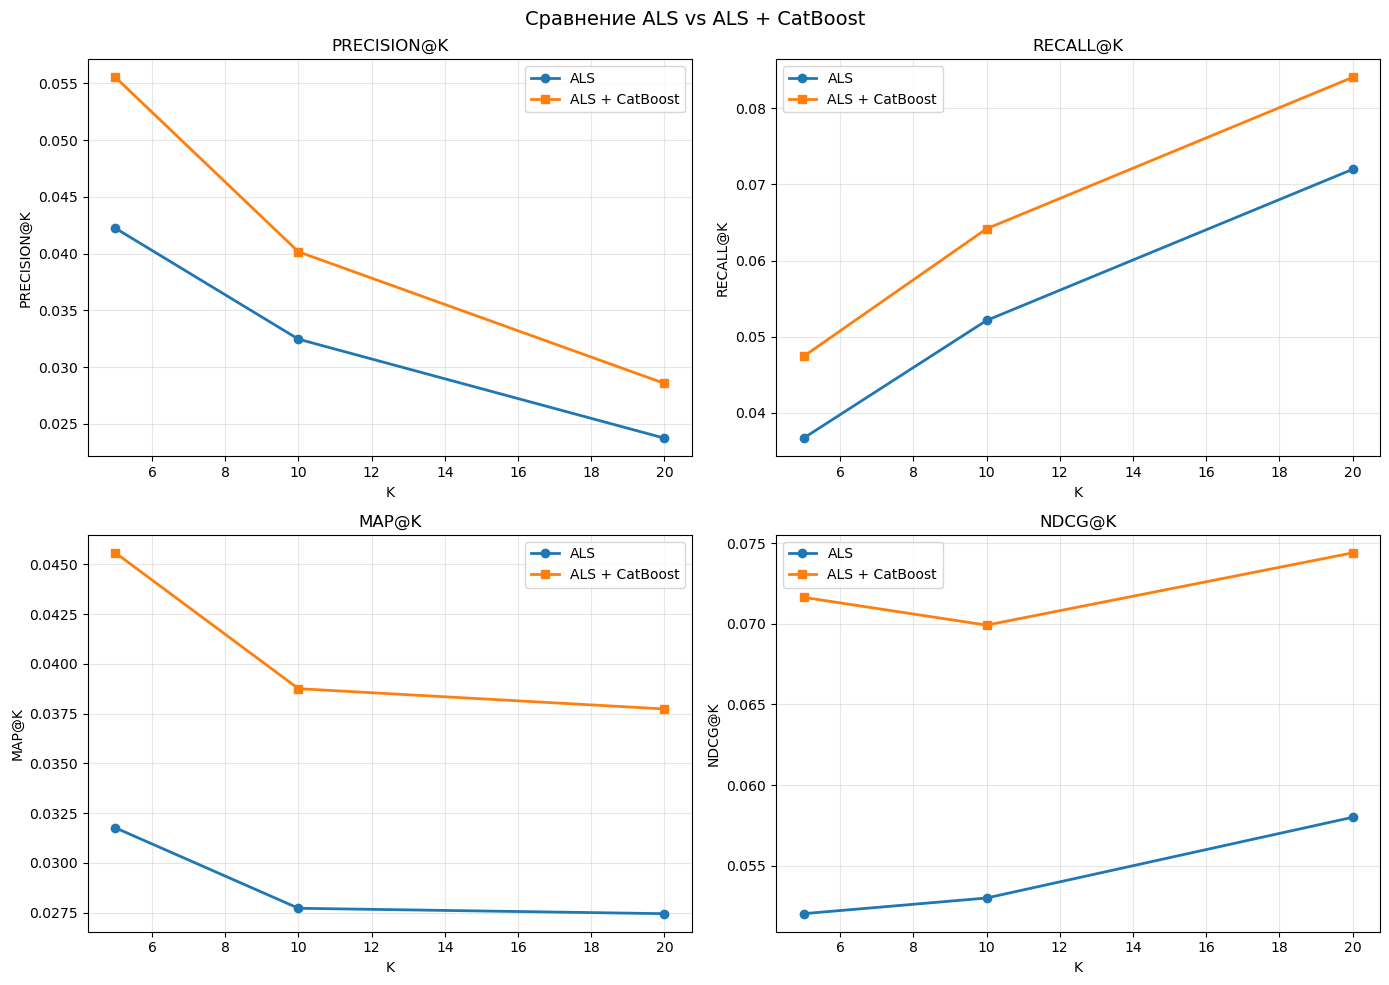

In [23]:
# Визуализация сравнения
metrics_list = ['precision', 'recall', 'map', 'ndcg']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flat, metrics_list):
    als_vals    = [als_results[k][metric] for k in k_values]
    hybrid_vals = [hybrid_results[k][metric] for k in k_values]
    ax.plot(k_values, als_vals,    marker='o', label='ALS', linewidth=2)
    ax.plot(k_values, hybrid_vals, marker='s', label='ALS + CatBoost', linewidth=2)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric.upper()}@K')
    ax.set_title(f'{metric.upper()}@K')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение ALS vs ALS + CatBoost', fontsize=14)
plt.tight_layout()
plt.show()